In [1]:
# If you are using colab, you can mount your google drive and access data from there
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Preprocessing
We interpolate then normalize the data. Each is done individually

In [2]:
# Replace with your own files
#!cp "/content/drive/My Drive/ramandata/conor/Train_Inputs.mat" .
#!cp "/content/drive/My Drive/ramandata/conor/Test_Inputs.mat" .

In [3]:
import os
import h5py
import numpy as np

base_path = '/content/drive/MyDrive/Tesi_Raman/Datasets/SpectraBreast/Raw'
file_list = [
    'SB001TT_map_ 785_2sec1_50Lx_02.h5',
    'SB002TT_map_ 785_2sec1_50Lx_01.h5',
    'SB003TT_map_ 785_2sec1_50Lx_01.h5',
    'SB004TT_map_ 785_2sec1_50Lx_01.h5'
]

all_spectra = []
all_labels = []
all_groups = []
asse_X = None

print("Loading SpectraBreast Maps...")
for file_name in file_list:
    file_path = os.path.join(base_path, file_name)
    if not os.path.exists(file_path):
        if os.path.exists(file_name):
            file_path = file_name
        else:
            print(f"File {file_name} not found. Skipping.")
            continue

    print(f"Loading {file_name}...")
    with h5py.File(file_path, 'r') as f:
        intensity = np.array(f['/ENTRY/data/intensity'], dtype=np.float32)
        if asse_X is None:
            asse_X = np.array(f['/ENTRY/data/raman_shift'], dtype=np.float32)

        # Spatial flatten (transform 3D map to 2D matrix: n_spectra x n_shift)
        spectra_2d = intensity.reshape(-1, intensity.shape[2])
        all_spectra.append(spectra_2d)

        # Assign dummy labels (1) for breast tumors and use the file name as the group
        all_labels.extend([1] * spectra_2d.shape[0])
        all_groups.extend([file_name] * spectra_2d.shape[0])

X_raw = np.vstack(all_spectra)
labels_final = np.array(all_labels)
groups_final = np.array(all_groups)

print(f"\nTotal spectra loaded: {X_raw.shape[0]}")
print(f"Shape of X axis: {asse_X.shape}")

Loading SpectraBreast Maps...
Loading SB001TT_map_ 785_2sec1_50Lx_02.h5...
Loading SB002TT_map_ 785_2sec1_50Lx_01.h5...
Loading SB003TT_map_ 785_2sec1_50Lx_01.h5...
Loading SB004TT_map_ 785_2sec1_50Lx_01.h5...

Total spectra loaded: 52992
Shape of X axis: (1015,)


In [4]:
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, medfilt
from scipy import sparse
from scipy.sparse.linalg import spsolve
from tqdm import tqdm
import numpy as np

def remove_cosmic_rays_fast(spectra, threshold=7):
    """Fast vectorized cosmic ray removal using a median filter and modified Z-score."""
    med_spectra = medfilt(spectra, kernel_size=(1, 5))
    diff = np.abs(spectra - med_spectra)
    mad = np.median(diff, axis=1, keepdims=True)
    mad[mad == 0] = 1e-6
    modified_z_score = 0.6745 * diff / mad
    spikes = modified_z_score > threshold
    despiked = np.copy(spectra)
    despiked[spikes] = med_spectra[spikes]
    return despiked

def baseline_als(y, lam=100000, p=0.01, niter=10):
    """Asymmetric Least Squares (ALS) for baseline estimation."""
    L = len(y)
    D = sparse.diags([1,-2,1],[0,-1,-2], shape=(L,L-2))
    D = lam * D.dot(D.transpose())
    w = np.ones(L)
    for i in range(niter):
        W = sparse.spdiags(w, 0, L, L)
        Z = W + D
        z = spsolve(Z.tocsc(), w*y)
        w = p * (y > z) + (1-p) * (y < z)
    return z

# 1. Cosmic Ray Removal (fast vectorized)
print("Removing Cosmic Rays (vectorized)...")
X_despiked = remove_cosmic_rays_fast(X_raw)

# 2. Smoothing
print("Savitzky-Golay Smoothing...")
X_smooth = savgol_filter(X_despiked, window_length=11, polyorder=3, axis=1)

# 3. Baseline Correction (ALS)
print("Baseline Correction (ALS) on all spectra...")
X_baseline_corrected = np.zeros_like(X_smooth)
baselines = np.zeros_like(X_smooth)
for i in tqdm(range(X_smooth.shape[0]), desc="ALS"):
    bl = baseline_als(X_smooth[i], lam=1e5, p=0.01)
    baselines[i] = bl
    X_baseline_corrected[i] = X_smooth[i] - bl

# Update X_raw WITHOUT applying L2 and WITHOUT cropping the frequencies here!
X_raw_pre_cr = np.copy(X_raw)
X_raw = X_baseline_corrected.astype(np.float32)


Removing Cosmic Rays (vectorized)...
Savitzky-Golay Smoothing...
Baseline Correction (ALS) on all spectra...


ALS: 100%|██████████| 52992/52992 [08:24<00:00, 105.00it/s]


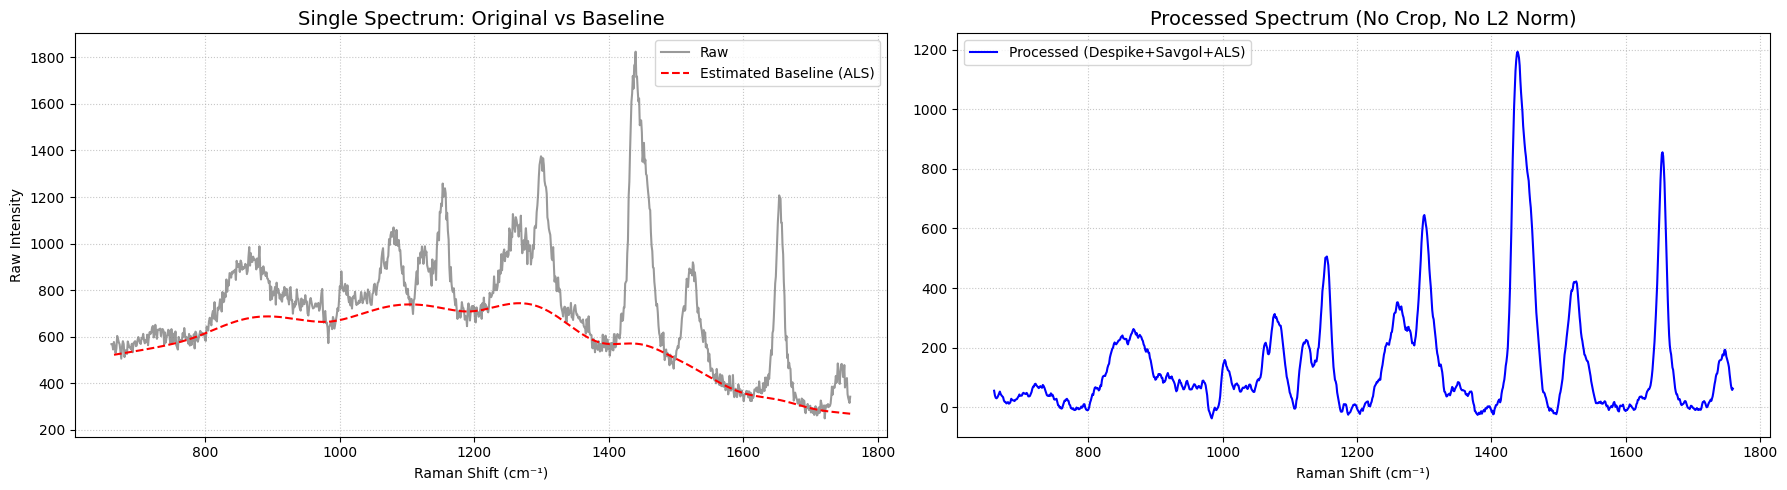

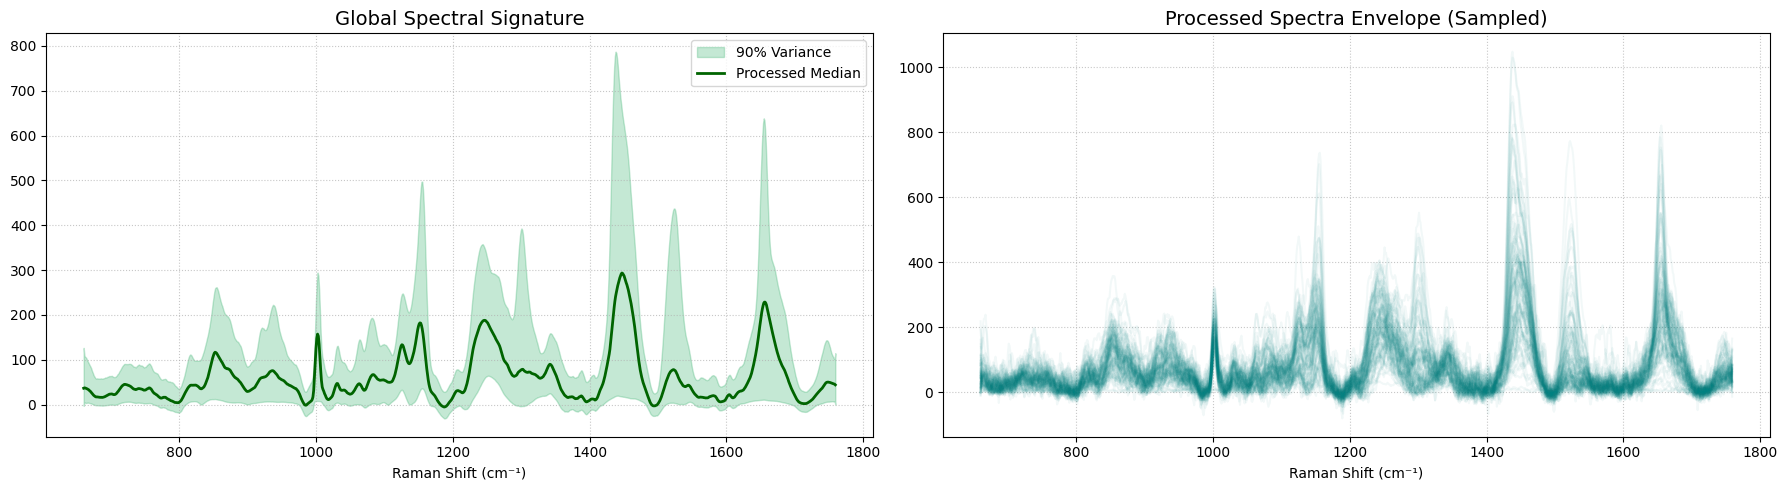

In [5]:
# --- PLOTTING ---
sample_idx = X_raw.shape[0] // 2
median_proc = np.median(X_raw, axis=0)
p5_proc = np.percentile(X_raw, 5, axis=0)
p95_proc = np.percentile(X_raw, 95, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# 1. Single Spectrum
axes[0].plot(asse_X, X_raw_pre_cr[sample_idx], color='gray', label='Raw', alpha=0.8)
axes[0].plot(asse_X, baselines[sample_idx], color='red', linestyle='--', label='Estimated Baseline (ALS)')
axes[0].set_title("Single Spectrum: Original vs Baseline", fontsize=14)
axes[0].set_xlabel("Raman Shift (cm⁻¹)")
axes[0].set_ylabel("Raw Intensity")
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.7)

# 2. Processed Spectrum
axes[1].plot(asse_X, X_raw[sample_idx], color='blue', linewidth=1.5, label='Processed (Despike+Savgol+ALS)')
axes[1].set_title("Processed Spectrum (No Crop, No L2 Norm)", fontsize=14)
axes[1].set_xlabel("Raman Shift (cm⁻¹)")
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(18, 5))

# 3. Global Median Spectral Signature
axes2[0].fill_between(asse_X, p5_proc, p95_proc, color='mediumseagreen', alpha=0.3, label='90% Variance')
axes2[0].plot(asse_X, median_proc, color='darkgreen', linewidth=2, label='Processed Median')
axes2[0].set_title("Global Spectral Signature", fontsize=14)
axes2[0].set_xlabel("Raman Shift (cm⁻¹)")
axes2[0].legend()
axes2[0].grid(True, linestyle=':', alpha=0.7)

# 4. Processed Spectra Envelope
subset = X_raw[::max(1, X_raw.shape[0] // 100)] # Plot 1% of spectra to be safe
for spec in subset:
    axes2[1].plot(asse_X, spec, color='teal', alpha=0.05)
axes2[1].set_title("Processed Spectra Envelope (Sampled)", fontsize=14)
axes2[1].set_xlabel("Raman Shift (cm⁻¹)")
axes2[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()


In [6]:
from scipy import interpolate
from tqdm import tqdm

def interpolate_spectra(spectra_data, old_wavelengths, new_points=1000):
    # Create new wavelength points (evenly spaced)
    new_wavelengths = np.linspace(
        old_wavelengths[0],
        old_wavelengths[-1],
        new_points
    )

    # Initialize array for interpolated spectra
    interpolated_spectra = np.zeros((spectra_data.shape[0], new_points))

    # Interpolate each spectrum
    for i in tqdm(range(spectra_data.shape[0])):
        # Create cubic spline interpolation function
        f = interpolate.CubicSpline(old_wavelengths, spectra_data[i, :])

        # Apply interpolation to new wavelength points
        interpolated_spectra[i, :] = f(new_wavelengths)

    return interpolated_spectra, new_wavelengths

In [7]:
def normalize_raman_spectra(spectra):
    # Create output array
    normalized = np.zeros_like(spectra)

    # Normalize each spectrum individually
    for i in tqdm(range(spectra.shape[0])):
        spectrum = spectra[i, :]
        min_val = np.min(spectrum)
        max_val = np.max(spectrum)

        if max_val > min_val:
            # Min-max normalization to [0,1] range
            normalized[i, :] = (spectrum - min_val) / (max_val - min_val)
        else:
            # Prevent division by zero for flat spectra
            normalized[i, :] = 0.0

    return normalized

In [18]:
# Global parameters for the new wavelength axis
MIN_WAVE = 670
MAX_WAVE = 1750
NUM_PUNTI = 1000

# Creation of the new equally spaced target axis
new_wavelengths = np.linspace(MIN_WAVE, MAX_WAVE, NUM_PUNTI)
print(f"New target axis created: from {MIN_WAVE} to {MAX_WAVE} with {NUM_PUNTI} points.")

# Adapt the X axis to 1D format
asse_X_flat = asse_X.flatten()

# Interpolation requires a strictly increasing x axis.
# If asse_X_flat is decreasing, we invert it
sort_idx = np.argsort(asse_X_flat)
asse_X_sorted = asse_X_flat[sort_idx]
X_raw_sorted = X_raw[:, sort_idx]

# Use interpolation
interpolated_spectra = np.zeros((X_raw_sorted.shape[0], NUM_PUNTI), dtype=np.float32)
for i in tqdm(range(X_raw_sorted.shape[0])):
    f = interpolate.CubicSpline(asse_X_sorted, X_raw_sorted[i, :])
    interpolated_spectra[i, :] = f(new_wavelengths)


New target axis created: from 670 to 1750 with 1000 points.


100%|██████████| 52992/52992 [00:23<00:00, 2255.39it/s]


In [19]:
normalized_spectra = normalize_raman_spectra(interpolated_spectra)
normalized_spectra.shape

100%|██████████| 52992/52992 [00:00<00:00, 96137.93it/s]


(52992, 1000)

In [20]:
import os

# Requested save path
save_dir = '/content/drive/MyDrive/Tesi_Raman/Datasets/Processed/1000_pt/FingerPrint/Min-Max'
os.makedirs(save_dir, exist_ok=True) # Create the folder if it doesn't exist

save_path = os.path.join(save_dir, 'SpectraBreast_1000pt_FingerPrint.npz')

# Save the normalized spectra, the new x axis, the labels, and the groups
np.savez(save_path,
          spectra=normalized_spectra.astype(np.float32),
          wavelengths=new_wavelengths.astype(np.float32),
          labels=labels_final,
          groups=groups_final)

print(f"SpectraBreast dataset standardized and saved in: {save_path}")

SpectraBreast dataset standardized and saved in: /content/drive/MyDrive/Tesi_Raman/Datasets/Processed/1000_pt/FingerPrint/Min-Max/SpectraBreast_1000pt_FingerPrint.npz


In [21]:
# Verification cell to check the saved .npz file
import numpy as np

# Load the saved file
saved_data = np.load(save_path)

# Extract arrays
saved_spectra = saved_data['spectra']
saved_wavelengths = saved_data['wavelengths']

# Print verification details
print("--- Verification of Saved Data ---")
print(f"File loaded from: {save_path}")
print(f"Spectra shape: {saved_spectra.shape}")
print(f"Wavelengths shape: {saved_wavelengths.shape}")
print(f"Wavelength range: from {saved_wavelengths.min():.2f} cm^-1 to {saved_wavelengths.max():.2f} cm^-1")

# Double check if it strictly matches the desired range
if np.isclose(saved_wavelengths.min(), MIN_WAVE) and np.isclose(saved_wavelengths.max(), MAX_WAVE):
    print("\n\u2705 The wavelength axis is perfectly cropped to the requested range!")
else:
    print("\n\u26a0\ufe0f Warning: The wavelength axis does NOT match the requested range.")

--- Verification of Saved Data ---
File loaded from: /content/drive/MyDrive/Tesi_Raman/Datasets/Processed/1000_pt/FingerPrint/Min-Max/SpectraBreast_1000pt_FingerPrint.npz
Spectra shape: (52992, 1000)
Wavelengths shape: (1000,)
Wavelength range: from 670.00 cm^-1 to 1750.00 cm^-1

✅ The wavelength axis is perfectly cropped to the requested range!


# Plot Comparison
These plots are used in Several figures throughout the RamanFoundation paper

In [22]:
import matplotlib.pyplot as plt
plt.style.use('default')

FONTSIZE_AXIS = 15
FONTSIZE_TITLE=15

In [23]:
# Helpers
def get_spectra_from_range(spectra, wavelengths, wavelength_range):
  # Find indices of wavelengths within the range
  indices = np.where((wavelengths >= wavelength_range[0]) &
                     (wavelengths <= wavelength_range[1]))[0]

  # Extract the corresponding spectra
  extracted_spectra = spectra[indices]
  extracted_wavelengths = wavelengths[indices]

  return extracted_wavelengths, extracted_spectra

This plot is used to provide an example of interpolation in Figure 3

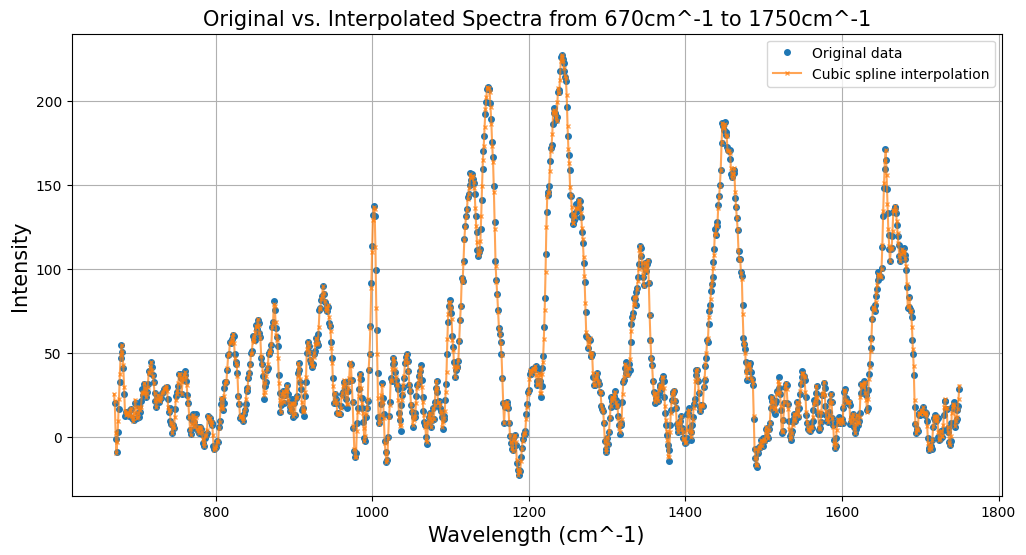

In [24]:
wavelength_range = (MIN_WAVE, MAX_WAVE)
sample_idx = 0

training_sample = X_raw[sample_idx]
interpolated_sample = interpolated_spectra[sample_idx]

wavelengths_original, spectra_original = get_spectra_from_range(training_sample, asse_X_flat, wavelength_range)
wavelengths_interpolated, spectra_interpolated = get_spectra_from_range(interpolated_sample, new_wavelengths, wavelength_range)

plt.figure(figsize=(12,6))
plt.plot(wavelengths_original, spectra_original,
        'o', label='Original data', markersize=4)
plt.plot(wavelengths_interpolated, spectra_interpolated,
          'x-', label='Cubic spline interpolation', alpha=0.7, markersize=3)

plt.xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
plt.ylabel('Intensity', fontsize=FONTSIZE_AXIS)
plt.title(f'Original vs. Interpolated Spectra from {wavelength_range[0]}cm^-1 to {wavelength_range[1]}cm^-1', fontsize=FONTSIZE_TITLE)
plt.legend()
plt.grid(True)
plt.show()

This plot is used to show normalization in Figure 3

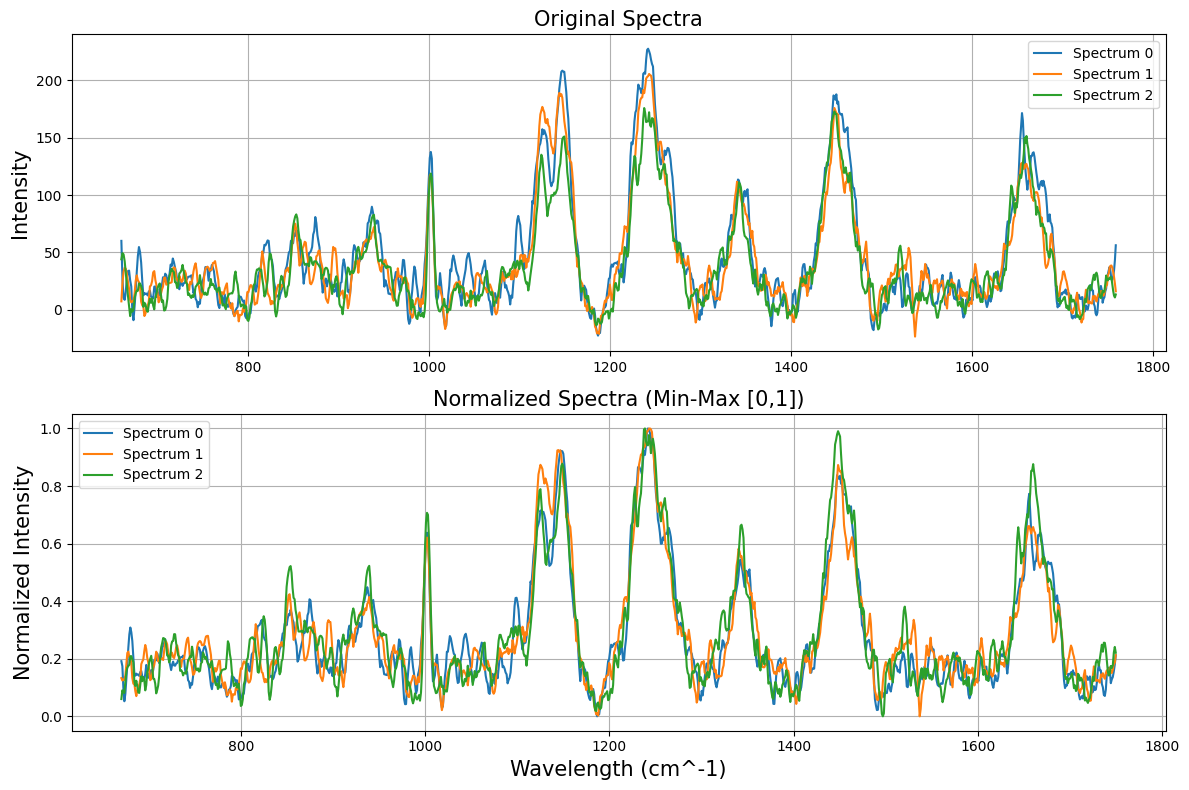

In [25]:
def plot_normalization_comparison(original_spectra, normalized_spectra, sample_indices=[0,1,2]):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

    # Plot original spectra
    for idx in sample_indices:
        ax1.plot(asse_X_flat, original_spectra[idx], label=f'Spectrum {idx}')
    ax1.set_title('Original Spectra', fontsize=FONTSIZE_TITLE)
    # ax1.set_xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
    ax1.set_ylabel('Intensity', fontsize=FONTSIZE_AXIS)
    ax1.legend()
    ax1.grid(True)

    # Plot normalized spectra
    for idx in sample_indices:
        ax2.plot(new_wavelengths, normalized_spectra[idx], label=f'Spectrum {idx}')
    ax2.set_title('Normalized Spectra (Min-Max [0,1])', fontsize=FONTSIZE_TITLE)
    ax2.set_xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
    ax2.set_ylabel('Normalized Intensity', fontsize=FONTSIZE_AXIS)
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()


# Plot comparison
plot_normalization_comparison(X_raw, normalized_spectra)

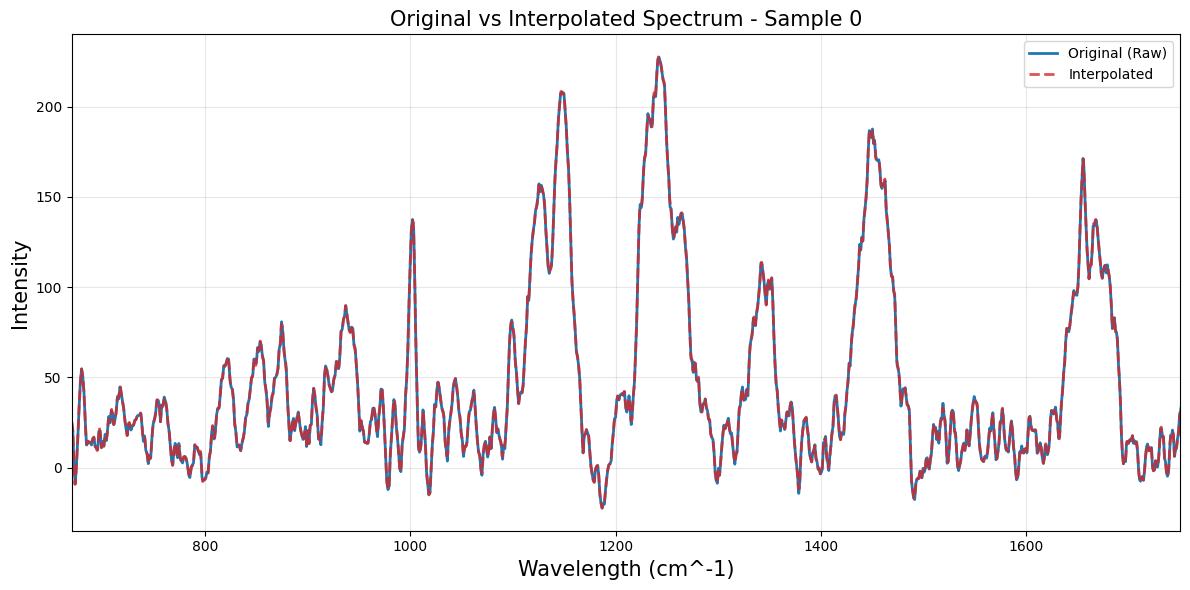

In [26]:
# Overlay of original and interpolated spectra to verify shape preservation
sample_idx = 0
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Original Spectrum
ax.plot(asse_X_flat, X_raw[sample_idx], color='tab:blue', label='Original (Raw)', linewidth=2)
# Plot Interpolated Spectrum
ax.plot(new_wavelengths, interpolated_spectra[sample_idx], color='tab:red', linestyle='--', alpha=0.8, label='Interpolated', linewidth=2)

# Formatting the plot
ax.set_xlabel('Wavelength (cm^-1)', fontsize=FONTSIZE_AXIS)
ax.set_ylabel('Intensity', fontsize=FONTSIZE_AXIS)
ax.set_xlim([MIN_WAVE, MAX_WAVE])
ax.set_title(f'Original vs Interpolated Spectrum - Sample {sample_idx}', fontsize=FONTSIZE_TITLE)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

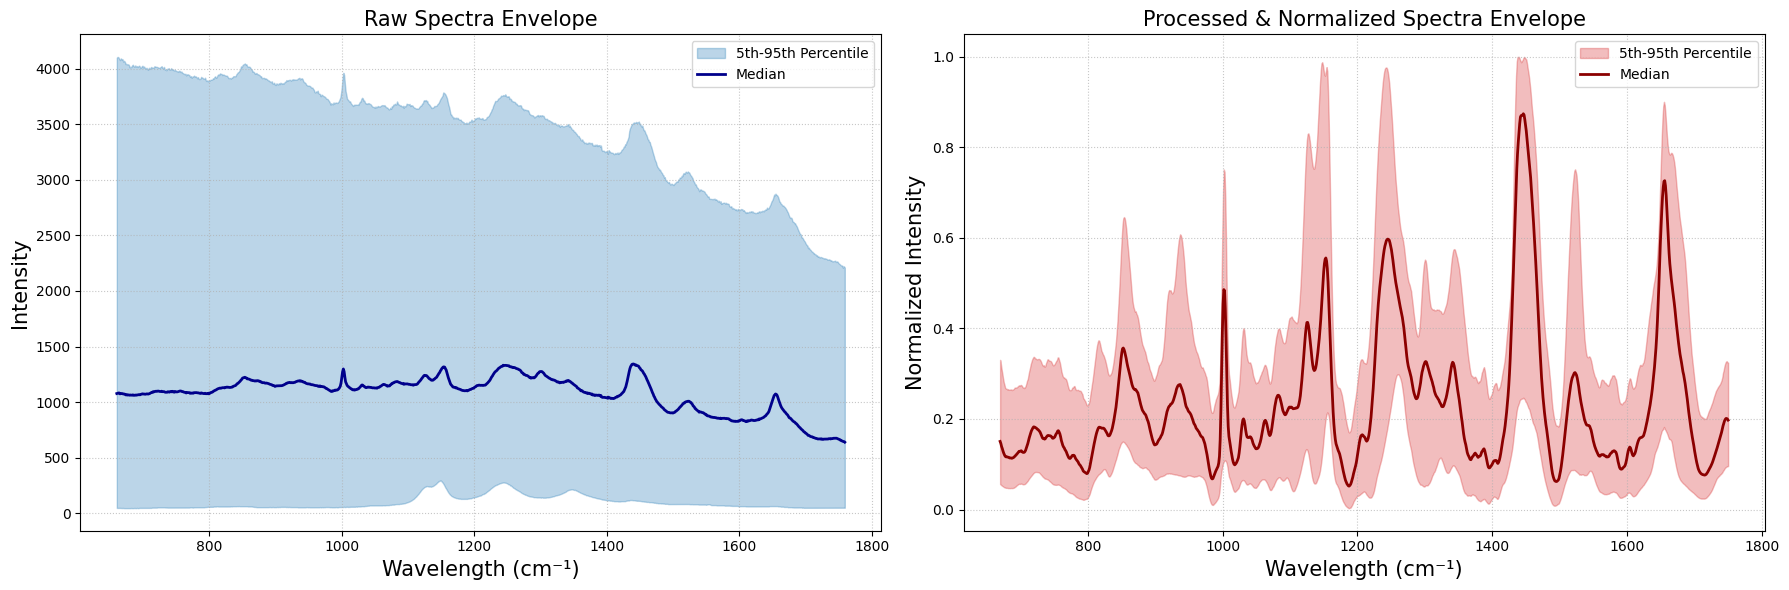

In [27]:
# Comparison of Envelopes: Raw vs Processed & Normalized
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Raw Spectra Envelope
# Calculate percentiles for the original raw data before any processing
raw_p5 = np.percentile(X_raw_pre_cr, 5, axis=0)
raw_p95 = np.percentile(X_raw_pre_cr, 95, axis=0)
raw_median = np.median(X_raw_pre_cr, axis=0)

axes[0].fill_between(asse_X_flat, raw_p5, raw_p95, color='tab:blue', alpha=0.3, label='5th-95th Percentile')
axes[0].plot(asse_X_flat, raw_median, color='darkblue', linewidth=2, label='Median')
axes[0].set_title('Raw Spectra Envelope', fontsize=FONTSIZE_TITLE)
axes[0].set_xlabel('Wavelength (cm⁻¹)', fontsize=FONTSIZE_AXIS)
axes[0].set_ylabel('Intensity', fontsize=FONTSIZE_AXIS)
axes[0].legend()
axes[0].grid(True, linestyle=':', alpha=0.7)

# 2. Processed & Normalized Spectra Envelope
# Calculate percentiles for the final normalized data
new_p5 = np.percentile(normalized_spectra, 5, axis=0)
new_p95 = np.percentile(normalized_spectra, 95, axis=0)
new_median = np.median(normalized_spectra, axis=0)

axes[1].fill_between(new_wavelengths, new_p5, new_p95, color='tab:red', alpha=0.3, label='5th-95th Percentile')
axes[1].plot(new_wavelengths, new_median, color='darkred', linewidth=2, label='Median')
axes[1].set_title('Processed & Normalized Spectra Envelope', fontsize=FONTSIZE_TITLE)
axes[1].set_xlabel('Wavelength (cm⁻¹)', fontsize=FONTSIZE_AXIS)
axes[1].set_ylabel('Normalized Intensity', fontsize=FONTSIZE_AXIS)
axes[1].legend()
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()